In [1]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [3]:
df.shape

(7043, 21)

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [7]:
df.dropna(inplace=True)

In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

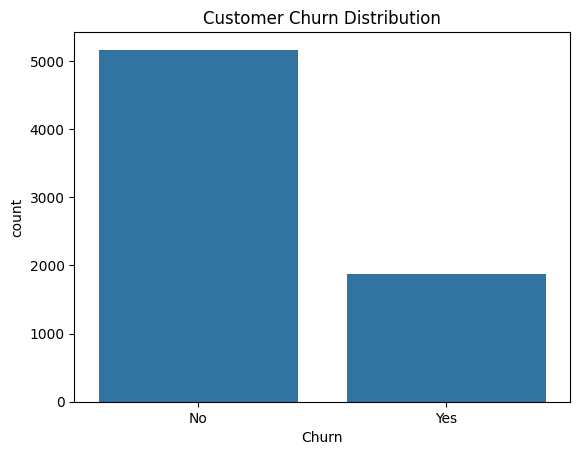

In [10]:
sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")

plt.show()

Observation: Most customers are retained, but a considerable number of customers have churned.


Business insight: Customer churn may lead to significant revenue loss if retention strategies are not improved.

Recommendation:The company should identify at-risk customers and implement targeted retention programs.

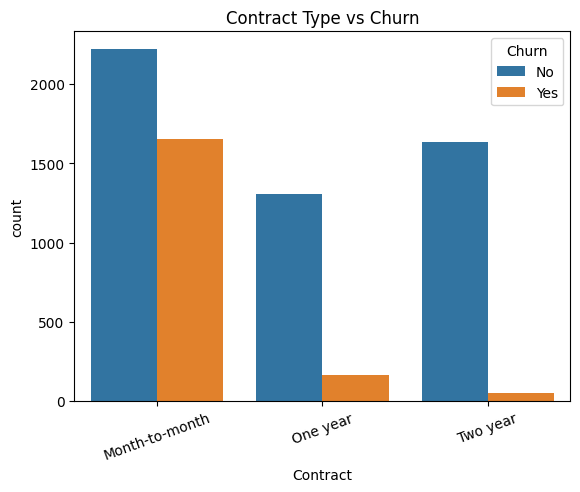

In [11]:
sns.countplot(x='Contract', hue='Churn', data=df)

plt.xticks(rotation=20)

plt.title("Contract Type vs Churn")

plt.show()

Observation: Customers with month-to-month contracts show the highest churn compared to one-year and two-year contracts.

Business Insight: Long-term contracts significantly improve customer retention and reduce churn probability.

Recommendation: The company should encourage customers to switch to long-term contracts through discounts and loyalty benefits.

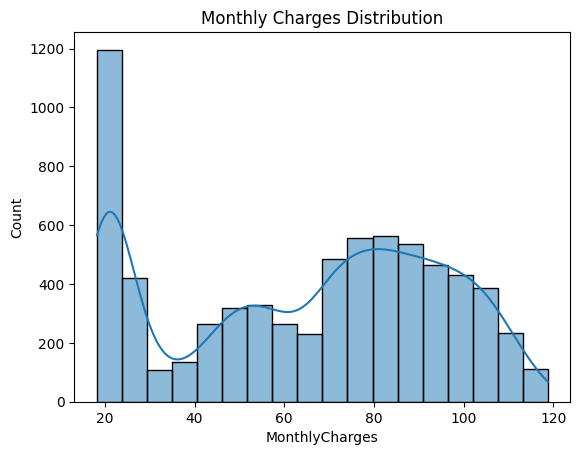

In [12]:
sns.histplot(df['MonthlyCharges'], kde=True)

plt.title("Monthly Charges Distribution")

plt.show()

Observation: Most customers have medium to high monthly charges, while fewer customers fall into the low-charge category.

Business Insight: Customers with higher monthly charges may have a greater likelihood of churn due to increased financial burden.

Recommendation:The company should offer affordable plans, discounts, or personalized pricing strategies to reduce churn among high-paying customers.

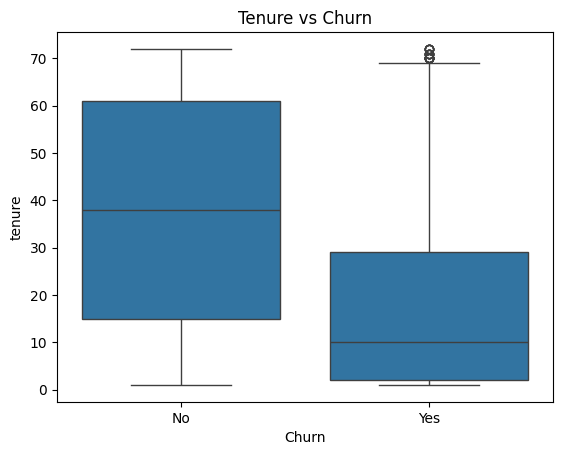

In [13]:
sns.boxplot(x='Churn', y='tenure', data=df)

plt.title("Tenure vs Churn")

plt.show()

Observation: Customers with lower tenure are more likely to churn, while long-term customers are mostly retained.

Business Insight: Customer loyalty increases with tenure, indicating that long-term customers have a lower churn probability.

Recommendation:The company should focus on improving early customer engagement and retention strategies for new customers.

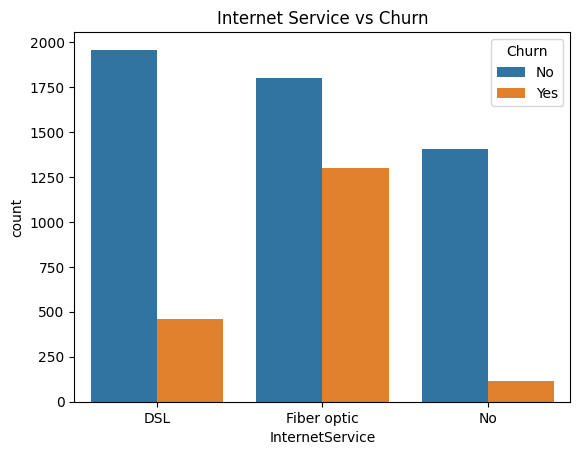

In [14]:
sns.countplot(x='InternetService', hue='Churn', data=df)

plt.title("Internet Service vs Churn")

plt.show()

Observation: Customers using fiber optic internet services have the highest churn compared to DSL and non-internet users.

Business Insight: Higher churn among fiber optic users may indicate dissatisfaction related to pricing, service quality, or customer expectations.

Recommendation: The company should improve fiber optic service quality and offer better pricing or support plans to reduce churn.

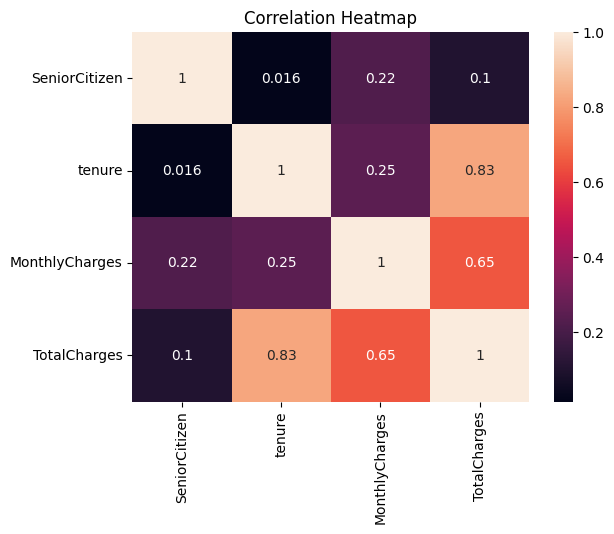

In [15]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)

plt.title("Correlation Heatmap")

plt.show()

Observation: Tenure and TotalCharges show a strong positive correlation, while MonthlyCharges has a moderate correlation with TotalCharges.

Business Insight: Customers who stay longer with the company contribute higher overall revenue through increased total charges.

Recommendation:The company should prioritize long-term customer retention strategies to maximize customer lifetime value and revenue growth.

In [16]:
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

In [17]:
df = pd.get_dummies(df, drop_first=True)

In [18]:
from sklearn.model_selection import train_test_split

X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("=== LOGISTIC REGRESSION ===")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

=== LOGISTIC REGRESSION ===
Accuracy: 0.7789623312011372
              precision    recall  f1-score   support

           0       0.79      0.95      0.86      1033
           1       0.70      0.30      0.42       374

    accuracy                           0.78      1407
   macro avg       0.74      0.63      0.64      1407
weighted avg       0.77      0.78      0.74      1407



In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[985  48]
 [263 111]]


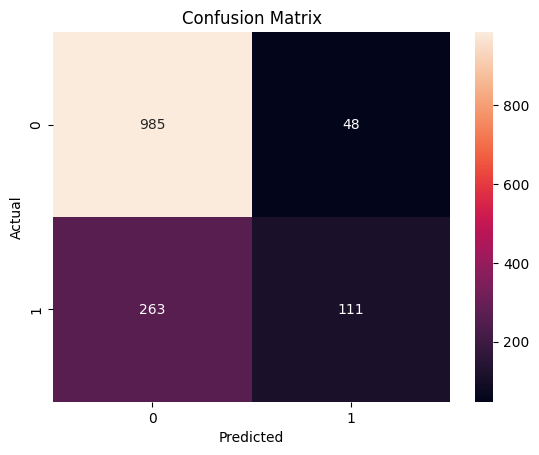

In [24]:
sns.heatmap(cm, annot=True, fmt='d')

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [26]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, rf_pred)

0.7889125799573561

In [27]:
from sklearn.metrics import classification_report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.86      1033
           1       0.65      0.44      0.52       374

    accuracy                           0.79      1407
   macro avg       0.74      0.68      0.69      1407
weighted avg       0.77      0.79      0.77      1407



In [28]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.7889125799573561


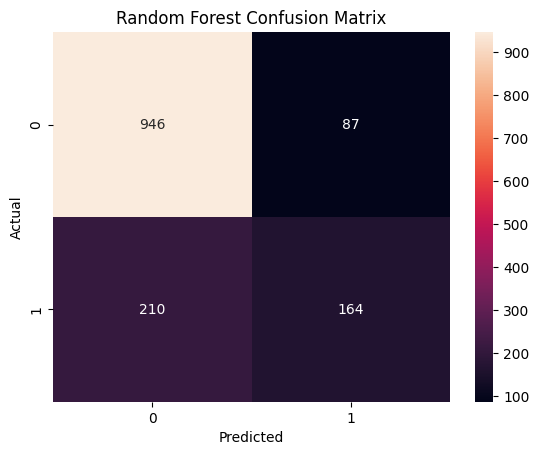

In [29]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(rf_cm, annot=True, fmt='d')

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Insight: Random Forest achieved slightly higher prediction accuracy than Logistic Regression for telecom customer churn prediction.

In [30]:
df.to_csv("cleaned_telco_churn.csv", index=False)

KeyboardInterrupt: 

In [31]:
dashboard_df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

dashboard_df['TotalCharges'] = pd.to_numeric(
    dashboard_df['TotalCharges'],
    errors='coerce'
)

dashboard_df.dropna(inplace=True)

dashboard_df.to_csv("powerbi_telco_churn.csv", index=False)

In [32]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances from Random Forest
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print(feature_importance)

                             Feature  Importance
3                       TotalCharges    0.098136
1                             tenure    0.095843
2                     MonthlyCharges    0.082386
7059  PaymentMethod_Electronic check    0.027770
7041     InternetService_Fiber optic    0.027204
7056               Contract_Two year    0.022274
7055               Contract_One year    0.020679
7044              OnlineSecurity_Yes    0.020568
7050                 TechSupport_Yes    0.020165
7057            PaperlessBilling_Yes    0.015982
